In [ ]:
import numpy as np
import pandas as pd
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from sklearn.model_selection import train_test_split

drive_path = '/content/drive/MyDrive/Datasets/PlantVillage'

all_images = []

for tumor_type in ['Potato___Late_blight', 'Potato___healthy', 'Potato___Early_blight']:
    class_path = os.path.join(drive_path, tumor_type)
    class_images = [os.path.join(class_path, img) for img in os.listdir(class_path)]
    all_images.extend(class_images)

labels = [os.path.dirname(img).split(os.path.sep)[-1] for img in all_images]

train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, labels, test_size=0.2, random_state=42, stratify=labels
)

def extract_labels(image_paths):
    return [os.path.dirname(img).split(os.path.sep)[-1] for img in image_paths]

X_train = train_images
Y_train = extract_labels(X_train)
X_test = test_images
Y_test = extract_labels(X_test)

print("Selected Training Images:", len(X_train))
print("Training Labels:", len(Y_train))
print("Selected Testing Images:", len(X_test))
print("Testing Labels:", len(Y_test))

Selected Training Images: 1721
Training Labels: 1721
Selected Testing Images: 431
Testing Labels: 431


In [ ]:
from collections import Counter

train_label_counts = Counter(Y_train)
test_label_counts = Counter(Y_test)

print("Training Label Counts:")
for label, count in train_label_counts.items():
    print(f"{label}: {count} images")

print("\nTesting Label Counts:")
for label, count in test_label_counts.items():
    print(f"{label}: {count} images")

Training Label Counts:
Potato___Early_blight: 800 images
Potato___Late_blight: 800 images
Potato___healthy: 121 images

Testing Label Counts:
Potato___Late_blight: 200 images
Potato___Early_blight: 200 images
Potato___healthy: 31 images


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
def preprocess_images(image_paths, target_size=(224, 224)):
    images = []
    for img_path in image_paths:
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img)
        images.append(img_array)
    return np.array(images,dtype="float16")

In [ ]:
import tensorflow as tf

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train_processed = preprocess_images(X_train)
X_test_processed = preprocess_images(X_test)

label_encoder = LabelEncoder()
Y_train = label_encoder.fit_transform(Y_train)
Y_test = label_encoder.transform(Y_test)

Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(4, activation='softmax'))

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_processed, Y_train, epochs=5, validation_data=(X_test_processed, Y_test))

Epoch 1/5
54/54 [==============================] - 7s 77ms/step - loss: 0.7968 - accuracy: 0.6880 - val_loss: 0.2682 - val_accuracy: 0.9118
Epoch 2/5
54/54 [==============================] - 2s 45ms/step - loss: 0.2808 - accuracy: 0.9035 - val_loss: 0.1530 - val_accuracy: 0.9490
Epoch 3/5
54/54 [==============================] - 2s 46ms/step - loss: 0.1865 - accuracy: 0.9372 - val_loss: 0.1216 - val_accuracy: 0.9606
Epoch 4/5
54/54 [==============================] - 2s 46ms/step - loss: 0.1517 - accuracy: 0.9477 - val_loss: 0.0906 - val_accuracy: 0.9745
Epoch 5/5
54/54 [==============================] - 2s 46ms/step - loss: 0.1210 - accuracy: 0.9622 - val_loss: 0.0917 - val_accuracy: 0.9698


In [ ]:
test_loss, test_acc = model.evaluate(X_test_processed, Y_test)
print(f'Test accuracy: {test_acc}')

14/14 [==============================] - 1s 34ms/step - loss: 0.0917 - accuracy: 0.9698
Test accuracy: 0.9698376059532166


In [ ]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
predicted_labels = model.predict(X_test_processed).argmax(axis=1)

misclassified_indices = []

for i in range(len(Y_test)):
    if predicted_labels[i] != Y_test[i]:
        misclassified_indices.append(i)
print(misclassified_indices)

14/14 [==============================] - 1s 34ms/step
[1, 23, 36, 78, 123, 233, 258, 262, 312, 314, 320, 384, 387]


In [ ]:
iteration_list=[]
accuracy_list=[]
misclassified_list=[]
iteration=0

iteration_list.append(iteration)
misclassified_list.append(len(misclassified_indices))
accuracy_list.append(test_acc)

In [ ]:
!pip install shap --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 9.8 MB/s eta 0:00:00


In [ ]:
import shap

# # Define a masker using a blurred background
masker = shap.maskers.Image("inpaint_telea", (224,224,3))

In [ ]:
shap_val=0

def custom_loss_with_weights(Y_test, predicted_labels, sample_weights):
    original_loss = tf.keras.losses.sparse_categorical_crossentropy(Y_test, predicted_labels, from_logits=True)
    sample_weights = tf.cast(tf.reshape(sample_weights, (-1, 1)), tf.float32)
    weighted_loss = tf.reduce_mean(tf.multiply(sample_weights, original_loss))
    return weighted_loss

In [ ]:
accuracy_threshold = 0.998

while True:
    explainer = shap.Explainer(model, masker, output_names=["notumor", "pituitary", "glioma", "meningioma"])
    misclassified_images = X_test_processed[misclassified_indices]
    shap_values = explainer(misclassified_images, max_evals=500, batch_size=16)

    retrained_model = models.clone_model(model)
    retrained_model.set_weights(model.get_weights())

    if iteration > 0:
        retrained_model.set_weights(previous_retrained_model.get_weights())

    for channel_index in range(X_train_processed.shape[-1]):
        shap_values_channel = shap_values[..., channel_index].values
        base_shap_values_channel = shap_values[..., channel_index].base_values

        positive_shap_mask = base_shap_values_channel > 0
        positive_shap_positions = np.where(positive_shap_mask)

        shap_values_difference = shap_values_channel - base_shap_values_channel[:, np.newaxis, np.newaxis, np.newaxis]

        delta_weight = np.mean(shap_values_difference[positive_shap_positions])
        delta_weight=tf.cast(delta_weight, tf.float32)

        sample_weights = np.ones_like(Y_train)
        sample_weights[Y_train == channel_index] += delta_weight

    X_train_appended = np.concatenate((X_train_processed, X_test_processed[misclassified_indices]))
    Y_train_appended = np.concatenate((Y_train, Y_test[misclassified_indices]))

    retrained_model.compile(optimizer=Adam(learning_rate=0.0001),loss=lambda true_labels, predicted_labels: custom_loss_with_weights(true_labels, predicted_labels, sample_weights), metrics=['accuracy'])

    retrained_model.fit(X_train_appended, Y_train_appended, epochs=10, validation_data=(X_test_processed, Y_test))

    iteration += 1

    test_loss, test_accuracy = retrained_model.evaluate(X_test_processed, Y_test)

    predicted_labels = retrained_model.predict(X_test_processed).argmax(axis=1)

    misclassified_indices = [i for i in range(len(Y_test)) if predicted_labels[i] != Y_test[i]]

    iteration_list.append(iteration)
    accuracy_list.append(test_accuracy)
    misclassified_list.append(len(misclassified_indices))

    previous_retrained_model = retrained_model

    print(f"Iteration {iteration} - Test Accuracy: {test_accuracy}")

    with open(f'Iteration_{iteration}_model.pkl', 'wb') as file:
        pickle.dump(retrained_model, file)

    if test_accuracy >= accuracy_threshold:
        print(f"Accuracy reached the threshold ({accuracy_threshold}). Stopping training.")
        break

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:   8%|▊         | 1/13 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:  23%|██▎       | 3/13 [00:36<01:34,  9.40s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...


PartitionExplainer explainer: 4it [00:58, 19.35s/it]


Epoch 1/10
54/54 [==============================] - 8s 87ms/step - loss: 0.0136 - accuracy: 0.9977 - val_loss: 0.0146 - val_accuracy: 0.9977
Epoch 2/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0130 - accuracy: 0.9971 - val_loss: 0.0168 - val_accuracy: 0.9884
Epoch 3/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0089 - accuracy: 0.9983 - val_loss: 0.0130 - val_accuracy: 1.0000
Epoch 4/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0109 - accuracy: 0.9971 - val_loss: 0.0154 - val_accuracy: 0.9954
Epoch 5/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0112 - accuracy: 0.9971 - val_loss: 0.0135 - val_accuracy: 0.9954
Epoch 6/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0092 - accuracy: 0.9977 - val_loss: 0.0204 - val_accuracy: 0.9884
Epoch 7/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0059 - accuracy: 0.9988 - val_loss: 0.0118 - val_accuracy: 0.9954
Epoch 8/10
54

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 2it [00:18, 18.36s/it]               


Epoch 1/10
54/54 [==============================] - 9s 87ms/step - loss: 0.0075 - accuracy: 0.9977 - val_loss: 0.0092 - val_accuracy: 1.0000
Epoch 2/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0053 - accuracy: 0.9988 - val_loss: 0.0097 - val_accuracy: 1.0000
Epoch 3/10
54/54 [==============================] - 3s 47ms/step - loss: 0.0070 - accuracy: 0.9988 - val_loss: 0.0091 - val_accuracy: 1.0000
Epoch 4/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0052 - accuracy: 0.9988 - val_loss: 0.0084 - val_accuracy: 1.0000
Epoch 5/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 0.0082 - val_accuracy: 1.0000
Epoch 6/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0037 - accuracy: 0.9994 - val_loss: 0.0093 - val_accuracy: 1.0000
Epoch 7/10
54/54 [==============================] - 2s 46ms/step - loss: 0.0033 - accuracy: 1.0000 - val_loss: 0.0109 - val_accuracy: 0.9977
Epoch 8/10
54

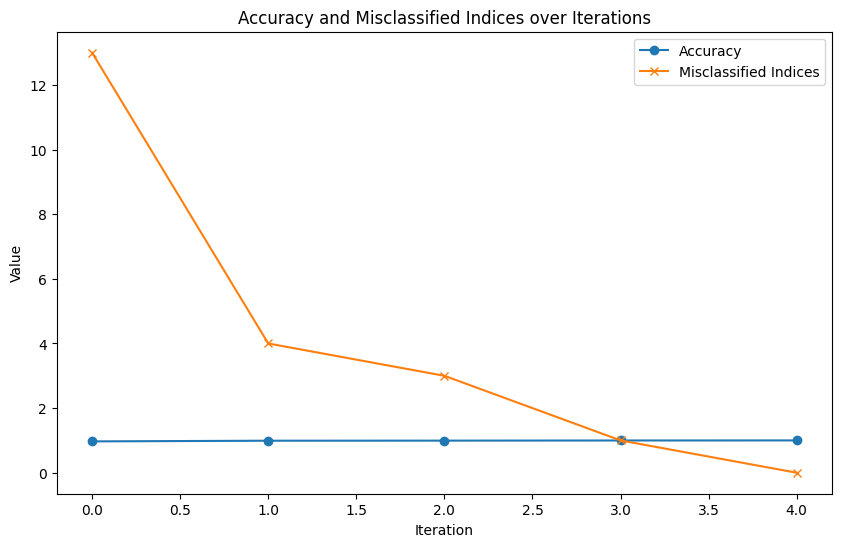

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(iteration_list, accuracy_list, label='Accuracy', marker='o')
plt.plot(iteration_list, misclassified_list, label='Misclassified Indices', marker='x')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Accuracy and Misclassified Indices over Iterations')
plt.legend()
plt.show()

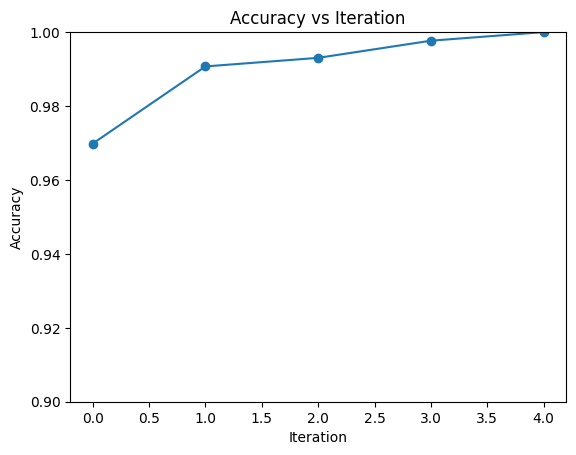

In [ ]:
plt.plot(iteration_list, accuracy_list, marker='o', linestyle='-')
plt.ylim(0.9, 1)

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Iteration')

plt.show()

In [ ]:
print(misclassified_list)

[13, 4, 3, 1, 0]


14/14 [==============================] - 0s 34ms/step
Confusion Matrix:
[[200   0   0]
 [  0 200   0]
 [  0   0  31]]


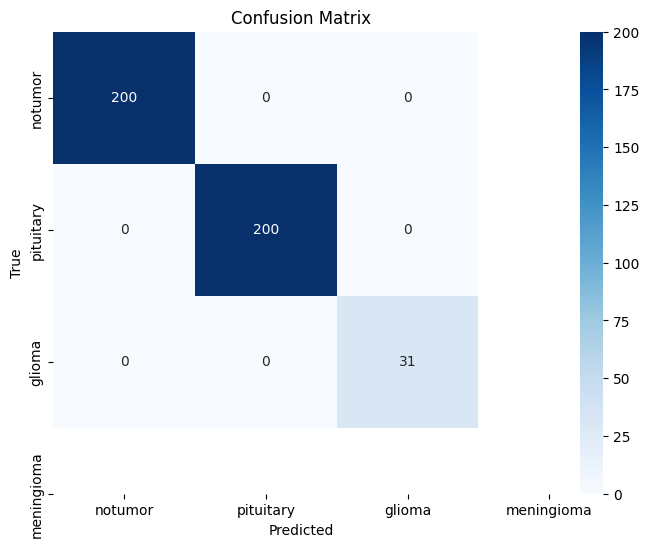

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
predicted_labels = retrained_model.predict(X_test_processed).argmax(axis=1)

conf_matrix = confusion_matrix(Y_test, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['notumor', 'pituitary', 'glioma', 'meningioma'], yticklabels=['notumor', 'pituitary', 'glioma', 'meningioma'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()